#Instalando las librerías necesarias

In [ ]:
!pip install pycaret[full]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.3/46.3 kB 3.0 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.0/111.0 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 13.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of flask to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 3.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
!pip install fastapi

In [ ]:
!pip install uvicorn

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from pycaret.utils import version
version()

'3.3.2'

In [ ]:
from pycaret.classification import *

In [ ]:
datos= "https://github.com/gchavez83/Analitica/raw/main/Salida_UADY_ML_25.xlsx" ##Bd llamadas desde github

In [ ]:
df = pd.read_excel(datos)
#df.drop(columns="Unnamed: 0", inplace=True)
df

,FOLIO CENEVAL,ESTATUS,Abv.1,Ciclo,POSICIÓN,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático
0,526498480,No admitido,MCI,2025,245,1248,1260
1,526501134,No admitido,MCI,2025,246,1248,1260
2,526505004,No admitido,MCI,2025,247,1248,1260
3,526553670,No admitido,MCI,2025,248,1248,1260
4,526583358,No admitido,MCI,2025,249,1248,1260
...,...,...,...,...,...,...,...
52870,526439751,Admitido,ADM,2025,166,1026,860
52871,526498771,Admitido,ADM,2025,167,1026,800
52872,526522232,Admitido,IST,2025,4,1074,760
52873,526467871,Admitido,IST,2025,19,961,840


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52875 entries, 0 to 52874
Data columns (total 7 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   FOLIO CENEVAL                       52875 non-null  int64 
 1   ESTATUS                             52875 non-null  object
 2   Abv.1                               52875 non-null  object
 3   Ciclo                               52875 non-null  int64 
 4   POSICIÓN                            52875 non-null  int64 
 5   Avg__Índice_Ceneval                 52875 non-null  int64 
 6   Avg__Índice_Pensamiento_Matemático  52875 non-null  int64 
dtypes: int64(5), object(2)
memory usage: 2.8+ MB


In [ ]:
df.describe()

,FOLIO CENEVAL,Ciclo,POSICIÓN,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático
count,5.287500e+04,52875.000000,52875.000000,52875.000000,52875.000000
mean,5.997773e+08,2023.491329,635.570704,1061.942998,1077.077258
std,1.247913e+08,1.136991,856.866642,77.693308,122.633464
min,4.271861e+08,2022.000000,1.000000,735.000000,700.000000
25%,5.264416e+08,2022.000000,89.000000,1004.000000,980.000000
50%,7.049758e+08,2023.000000,279.000000,1057.000000,1080.000000
75%,7.207829e+08,2025.000000,681.000000,1117.000000,1180.000000
max,7.225462e+08,2025.000000,3721.000000,1291.000000,1300.000000


In [ ]:
#df['ESTATUS'] = df['ESTATUS'].replace({"Admitido":1, "No admitido":0 })

In [ ]:
df.head(10)

,FOLIO CENEVAL,ESTATUS,Abv.1,Ciclo,POSICIÓN,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático
0,526498480,No admitido,MCI,2025,245,1248,1260
1,526501134,No admitido,MCI,2025,246,1248,1260
2,526505004,No admitido,MCI,2025,247,1248,1260
3,526553670,No admitido,MCI,2025,248,1248,1260
4,526583358,No admitido,MCI,2025,249,1248,1260
5,526626046,No admitido,MCI,2025,250,1248,1260
6,526629042,No admitido,MCI,2025,251,1248,1260
7,526444646,No admitido,MCI,2025,289,1243,1260
8,526553708,No admitido,MCI,2025,290,1243,1260
9,526560630,No admitido,MCI,2025,291,1243,1260


##División del Conjunto de Datos

In [ ]:
datos = df.sample(frac=0.75, random_state=0)
datos_no_vistos = df.drop(datos.index)

In [ ]:
datos.reset_index(inplace=True, drop=True)
datos_no_vistos.reset_index(inplace=True, drop=True)

In [ ]:
print("Datos para Modelar: " + str(datos.shape))
print("Datos no vistos para Predicciones: " + str(datos_no_vistos.shape))

Datos para Modelar: (39656, 7)
Datos no vistos para Predicciones: (13219, 7)


In [ ]:
clasificacion = setup(data = datos, target = "ESTATUS", session_id=123, ignore_features= ['Ciclo', 'FOLIO CENEVAL', 'POSICIÓN'], fix_imbalance= True, categorical_features = ['Abv.1'], max_encoding_ohe = 49)

,Description,Value
0,Session id,123
1,Target,ESTATUS
2,Target type,Binary
3,Target mapping,"Admitido: 0, No admitido: 1"
4,Original data shape,"(39656, 7)"
5,Transformed data shape,"(49227, 52)"
6,Transformed train set shape,"(37330, 52)"
7,Transformed test set shape,"(11897, 52)"
8,Ignore features,3
9,Numeric features,2


In [ ]:
get_config('X_train')

,Abv.1,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático
25293,MCI,1191,1260
19761,CPU,1183,1300
18593,MVZ,974,860
8590,ACT,1126,1280
15891,ENF,1130,1220
...,...,...,...
34433,MCI,1243,1280
19501,ODO,1043,900
1506,MCI,1130,1140
36105,MCI,1065,1080


In [ ]:
help(deploy_model)

Help on function deploy_model in module pycaret.classification.functional:

deploy_model(model, model_name: str, authentication: dict, platform: str = 'aws')
    This function deploys the transformation pipeline and trained model on cloud.
    
    
    Example
    -------
    >>> from pycaret.datasets import get_data
    >>> juice = get_data('juice')
    >>> from pycaret.classification import *
    >>> exp_name = setup(data = juice,  target = 'Purchase')
    >>> lr = create_model('lr')
    >>> # sets appropriate credentials for the platform as environment variables
    >>> import os
    >>> os.environ["AWS_ACCESS_KEY_ID"] = str("foo")
    >>> os.environ["AWS_SECRET_ACCESS_KEY"] = str("bar")
    >>> deploy_model(model = lr, model_name = 'lr-for-deployment', platform = 'aws', authentication = {'bucket' : 'S3-bucket-name'})
    
    
    Amazon Web Service (AWS) users:
        To deploy a model on AWS S3 ('aws'), the credentials have to be passed. The easiest way is to use environment
  

##Comparando algoritmos de Clasificación

In [ ]:
mejor_modelo = compare_models(sort = "Recall")

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.9435,0.9904,0.9435,0.9435,0.9435,0.8717,0.8717,2.7250
catboost,CatBoost Classifier,0.9435,0.9906,0.9435,0.9434,0.9434,0.8715,0.8716,32.0420
xgboost,Extreme Gradient Boosting,0.9427,0.9904,0.9427,0.9426,0.9426,0.8695,0.8696,1.8280
rf,Random Forest Classifier,0.9375,0.9858,0.9375,0.9375,0.9375,0.8580,0.8581,4.6990
et,Extra Trees Classifier,0.9362,0.9656,0.9362,0.9365,0.9363,0.8555,0.8557,6.4480
dt,Decision Tree Classifier,0.9337,0.9472,0.9337,0.9343,0.9339,0.8504,0.8506,0.9820
lr,Logistic Regression,0.9300,0.9848,0.9300,0.9329,0.9307,0.8444,0.8460,6.9520
gbc,Gradient Boosting Classifier,0.9253,0.9814,0.9253,0.9257,0.9254,0.8310,0.8311,4.6470
ada,Ada Boost Classifier,0.9213,0.9783,0.9213,0.9226,0.9216,0.8232,0.8237,1.9760
ridge,Ridge Classifier,0.9106,0.9821,0.9106,0.9220,0.9123,0.8068,0.8148,0.8070


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

In [ ]:
mejor_modelo

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)

In [ ]:
type(mejor_modelo)

lightgbm.sklearn.LGBMClassifier

##Creación del MODELO

In [ ]:
modelo = create_model("lightgbm")
print(modelo)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9438,0.9905,0.9438,0.9437,0.9437,0.8720,0.8720
1,0.9402,0.9900,0.9402,0.9405,0.9403,0.8648,0.8649
2,0.9384,0.9894,0.9384,0.9384,0.9384,0.8600,0.8600
3,0.9503,0.9924,0.9503,0.9508,0.9505,0.8879,0.8881
4,0.9449,0.9905,0.9449,0.9448,0.9448,0.8747,0.8747
5,0.9442,0.9906,0.9442,0.9444,0.9443,0.8738,0.8738
6,0.9478,0.9912,0.9478,0.9478,0.9478,0.8814,0.8814
7,0.9406,0.9895,0.9406,0.9403,0.9404,0.8643,0.8645
8,0.9402,0.9895,0.9402,0.9401,0.9402,0.8642,0.8642


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [ ]:
modelo_catboost = create_model("catboost")
print(modelo_catboost)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9431,0.9905,0.9431,0.9429,0.9430,0.8703,0.8703
1,0.9402,0.9903,0.9402,0.9405,0.9403,0.8648,0.8648
2,0.9391,0.9897,0.9391,0.9390,0.9391,0.8616,0.8616
3,0.9478,0.9923,0.9478,0.9482,0.9479,0.8822,0.8823
4,0.9438,0.9905,0.9438,0.9437,0.9438,0.8723,0.8723
5,0.9478,0.9911,0.9478,0.9476,0.9477,0.8811,0.8811
6,0.9492,0.9918,0.9492,0.9492,0.9492,0.8846,0.8847
7,0.9380,0.9896,0.9380,0.9378,0.9378,0.8585,0.8586
8,0.9424,0.9898,0.9424,0.9422,0.9422,0.8686,0.8687


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

In [ ]:
eda(display_format= 'svg')

NameError: name 'eda' is not defined

In [ ]:
config = clasificacion.get_config()
print (config)

{'pipeline', 'y_transformed', 'X_train_transformed', 'logging_param', 'html_param', 'exp_id', 'fold_shuffle_param', 'X_train', 'y_train_transformed', 'train', 'target_param', 'variables', 'test', 'y_test', 'USI', 'X', 'X_test_transformed', 'train_transformed', 'data', '_ml_usecase', 'exp_name_log', 'X_test', 'y_train', 'memory', 'X_transformed', 'dataset_transformed', 'idx', 'y', 'fix_imbalance', 'is_multiclass', 'dataset', 'gpu_param', 'gpu_n_jobs_param', 'variable_and_property_keys', '_available_plots', 'test_transformed', 'log_plots_param', 'y_test_transformed', 'fold_generator', 'fold_groups_param', 'seed', 'n_jobs_param'}


In [ ]:
type(modelo)

lightgbm.sklearn.LGBMClassifier

In [ ]:
#create_api(modelo, 'modelo_api')

In [ ]:
#!python modelo_api.py

In [ ]:
#!pip install pyngrok


In [ ]:
#from pyngrok import ngrok

# Inicia el servidor
!python modelo_api.py &

# Obtén la URL pública del túnel
public_url = ngrok.connect(8000).public_url

print(f"¡El servidor está disponible en {public_url}!")


python3: can't open file '/content/modelo_api.py': [Errno 2] No such file or directory


NameError: ignored

In [ ]:
create_app(modelo)

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://43174aca9c89ddd907.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
print(convert_model(modelo, language= 'php'))

<?php
function score(array $input) {
    $var0 = null;
    if ($input[49] > 1057.0927158394468) {
        if ($input[0] > 0.9892163938411803) {
            if ($input[49] > 1239.0037680874282) {
                $var0 = -0.17929883138564273;
            } else {
                if ($input[49] > 1206.5000000000002) {
                    $var0 = 0.0397456279809221;
                } else {
                    $var0 = 0.1925485122897801;
                }
            }
        } else {
            if ($input[49] > 1096.2520217145327) {
                if ($input[8] > 0.999687564956277) {
                    if ($input[49] > 1152.5042963173098) {
                        $var0 = -0.1945945945945946;
                    } else {
                        $var0 = 0.08698884758364313;
                    }
                } else {
                    $var0 = -0.18505467800729042;
                }
            } else {
                if ($input[2] > 0.9997554370767058) {
                    $var0

In [ ]:
optimizar_modelo = tune_model(modelo)
print(optimizar_modelo)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9434,0.9903,0.9434,0.9436,0.9435,0.8719,0.8719
1,0.9409,0.9890,0.9409,0.9414,0.9411,0.8666,0.8667
2,0.9377,0.9891,0.9377,0.9378,0.9377,0.8587,0.8587
3,0.9470,0.9919,0.9470,0.9482,0.9473,0.8812,0.8817
4,0.9452,0.9900,0.9452,0.9454,0.9453,0.8760,0.8760
5,0.9427,0.9904,0.9427,0.9431,0.9429,0.8707,0.8707
6,0.9474,0.9910,0.9474,0.9477,0.9475,0.8812,0.8813
7,0.9438,0.9894,0.9438,0.9436,0.9437,0.8719,0.8720
8,0.9427,0.9895,0.9427,0.9427,0.9427,0.8700,0.8700


Processing:   0%|          | 0/7 [00:00<?, ?it/s]

Fitting 10 folds for each of 10 candidates, totalling 100 fits


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [ ]:
print(convert_model(optimizar_modelo, language= 'php'))

<?php
function score(array $input) {
    $var0 = null;
    if ($input[50] > 1069.1005637796059) {
        if ($input[50] > 1160.8086781210934) {
            if ($input[13] > 0.0031534730465759835) {
                $var0 = -0.7605466177935994;
            } else {
                if ($input[10] > 0.000000000000000000000000000000000010000000180025095) {
                    $var0 = -0.7400816038416907;
                } else {
                    if ($input[50] > 1270.0000000000002) {
                        if ($input[9] > 0.09317710311902434) {
                            $var0 = -0.771343368868413;
                        } else {
                            if ($input[17] > 0.043654131211647525) {
                                $var0 = -0.781063974965295;
                            } else {
                                if ($input[50] > 1288.8315592032047) {
                                    $var0 = -0.5608090693846414;
                                } else {
                 

In [ ]:
#optimizar_modelo_2 = tune_model(modelo_2)
#print(optimizar_modelo)

##Visualización del MODELO

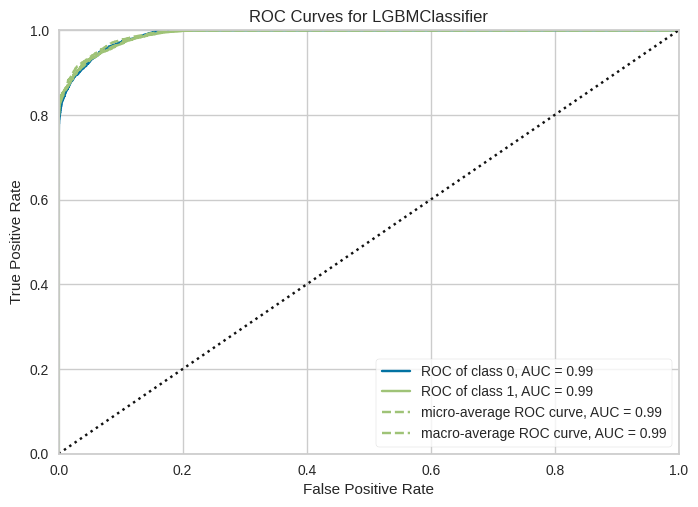

In [ ]:
plot_model(modelo, plot = 'auc')

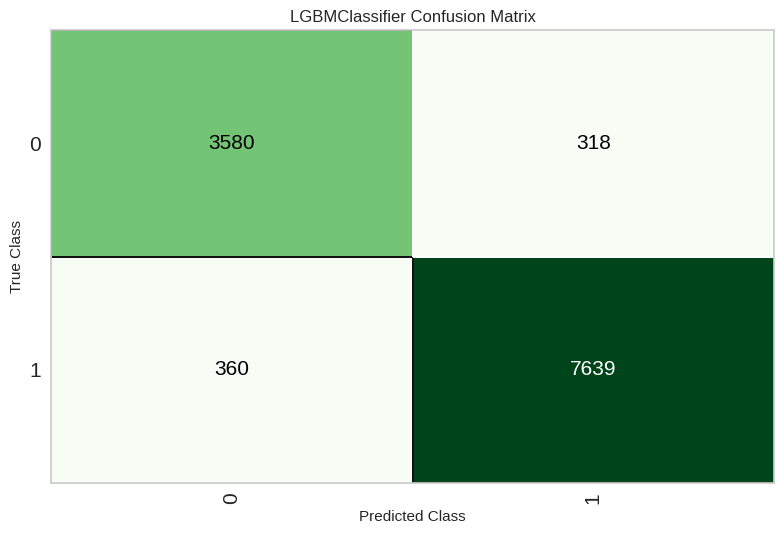

In [ ]:
plot_model(modelo, plot = 'confusion_matrix')

In [ ]:
evaluate_model(modelo)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [ ]:
predict_model(modelo)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9430,0.9907,0.9430,0.9432,0.9431,0.8710,0.8710


,Abv.1,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático,ESTATUS,prediction_label,prediction_score
9367,NUT,1052,1180,No admitido,No admitido,0.9783
24718,MCI,1187,1140,No admitido,No admitido,0.9975
18607,ARQ,996,980,No admitido,No admitido,0.9982
28950,MCI,996,900,No admitido,No admitido,0.9995
36192,CPU,1043,1160,Admitido,Admitido,0.9603
...,...,...,...,...,...,...
1603,ENF,943,880,No admitido,No admitido,0.9975
35186,ARQ,1122,1140,Admitido,Admitido,0.6133
39184,MCI,1157,1180,No admitido,No admitido,0.9971
10675,ARQ,1096,1140,Admitido,No admitido,0.8042


In [ ]:
final_modelo = finalize_model(modelo)
print(final_modelo)

Pipeline(memory=Memory(location=None),
         steps=[('label_encoding',
                 TransformerWrapperWithInverse(exclude=None, include=None,
                                               transformer=LabelEncoder())),
                ('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Avg__Índice_Ceneval',
                                             'Avg__Índice_Pensamiento_Matemático'],
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_emp...
                 LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                colsample_bytree=1.0, importance_type='split',
                                learning_rate=0.1, max_depth=-1,
        

In [ ]:
predict_model(final_modelo)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9487,0.9918,0.9487,0.9490,0.9488,0.8841,0.8842


,Abv.1,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático,ESTATUS,prediction_label,prediction_score
9367,NUT,1052,1180,No admitido,No admitido,0.9767
24718,MCI,1187,1140,No admitido,No admitido,0.9974
18607,ARQ,996,980,No admitido,No admitido,0.9975
28950,MCI,996,900,No admitido,No admitido,0.9994
36192,CPU,1043,1160,Admitido,Admitido,0.9543
...,...,...,...,...,...,...
1603,ENF,943,880,No admitido,No admitido,0.9976
35186,ARQ,1122,1140,Admitido,Admitido,0.6458
39184,MCI,1157,1180,No admitido,No admitido,0.9974
10675,ARQ,1096,1140,Admitido,No admitido,0.7193


##Predecir sobre datos no vistos

In [ ]:
datos_no_vistos_prediccion = predict_model(final_modelo, data=datos_no_vistos)
datos_no_vistos_prediccion.head()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.9421,0.9901,0.9421,0.9422,0.9422,0.8693,0.8693


,FOLIO CENEVAL,Abv.1,Ciclo,POSICIÓN,Avg__Índice_Ceneval,Avg__Índice_Pensamiento_Matemático,ESTATUS,prediction_label,prediction_score
0,526626046,MCI,2025,250,1248,1260,No admitido,Admitido,0.8500
1,526587929,MCI,2025,292,1243,1260,No admitido,Admitido,0.6412
2,526600118,MCI,2025,293,1243,1260,No admitido,Admitido,0.6412
3,526621044,MCI,2025,295,1243,1260,No admitido,Admitido,0.6412
4,526549705,MCI,2025,336,1239,1260,No admitido,No admitido,0.7713


In [ ]:
save_model(final_modelo,"/content/modelo_lightgbm_Uady_25")

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('label_encoding',
                  TransformerWrapperWithInverse(exclude=None, include=None,
                                                transformer=LabelEncoder())),
                 ('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Avg__Índice_Ceneval',
                                              'Avg__Índice_Pensamiento_Matemático'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_emp...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
                                 colsample_bytree=1.0, importance_type='split',
                                 learning_rate=0.1, max_dep